In [17]:
%load_ext autoreload
%autoreload 2
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt

from ocularrigidity.data.measurements.cohort import Study, build_cohort
from ocularrigidity.stats.plot import regression_plot_with_stats

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="The figure layout has changed to tight")
ROOT_CARDIAC = Path("/media/clement/HD/Santiago/OcularRigidity/FullPipeline/")

df = build_cohort(root=ROOT_CARDIAC, study=Study.PROSPECTIVE, overwrite=False)
n_patients = df.PatientId.nunique()
n_visits = len(df)


class DummyContextManager:
    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        pass


cm = plt.xkcd
cm = DummyContextManager

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


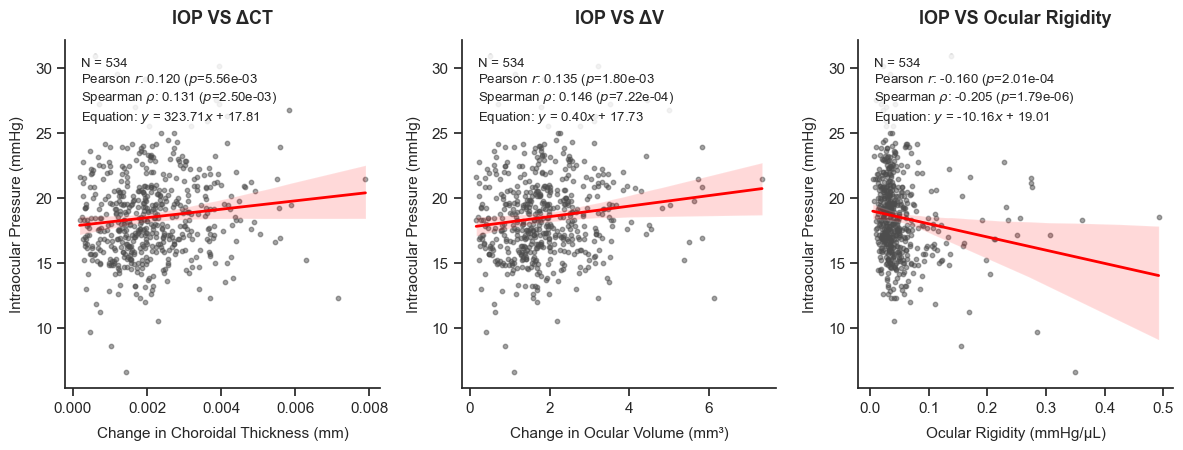

In [18]:
# | label: fig-K-vs-IOP-vs-dCT-vs-dV
with cm():
    fig, axes = plt.subplots(1, 3, figsize=(12, 14 / 3), constrained_layout=True)
    regression_plot_with_stats(
        df=df,
        x="K",
        y="IOP",
        xlabel="Ocular Rigidity (mmHg/μL)",
        ylabel="Intraocular Pressure (mmHg)",
        title="IOP VS Ocular Rigidity",
        ax=axes[2],
        equal_axis=False,
        print_stats=False,
    )
    regression_plot_with_stats(
        df=df,
        x="deltaCT",
        y="IOP",
        xlabel="Change in Choroidal Thickness (mm)",
        ylabel="Intraocular Pressure (mmHg)",
        title="IOP VS ΔCT",
        ax=axes[0],
        equal_axis=False,
        print_stats=False,
    )
    regression_plot_with_stats(
        df=df,
        x="dV",
        y="IOP",
        xlabel="Change in Ocular Volume (mm³)",
        ylabel="Intraocular Pressure (mmHg)",
        title="IOP VS ΔV",
        ax=axes[1],
        equal_axis=False,
        print_stats=False,
    )
plt.show()

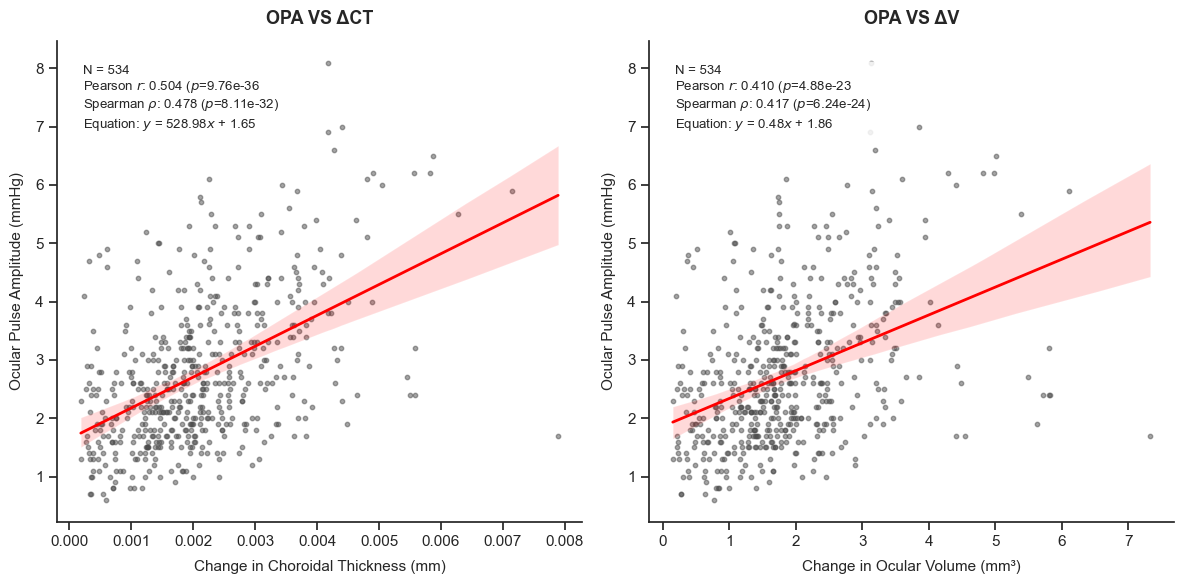

In [19]:
# | label: fig-deltaCT-dV-vs-OPA
with cm():
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
    regression_plot_with_stats(
        df=df,
        x="deltaCT",
        y="OPA",
        xlabel="Change in Choroidal Thickness (mm)",
        ylabel="Ocular Pulse Amplitude (mmHg)",
        title="OPA VS ΔCT",
        ax=axes[0],
        equal_axis=False,
        print_stats=False,
    )
    regression_plot_with_stats(
        df=df,
        x="dV",
        y="OPA",
        xlabel="Change in Ocular Volume (mm³)",
        ylabel="Ocular Pulse Amplitude (mmHg)",
        title="OPA VS ΔV",
        ax=axes[1],
        equal_axis=False,
        print_stats=False,
    )
plt.show()


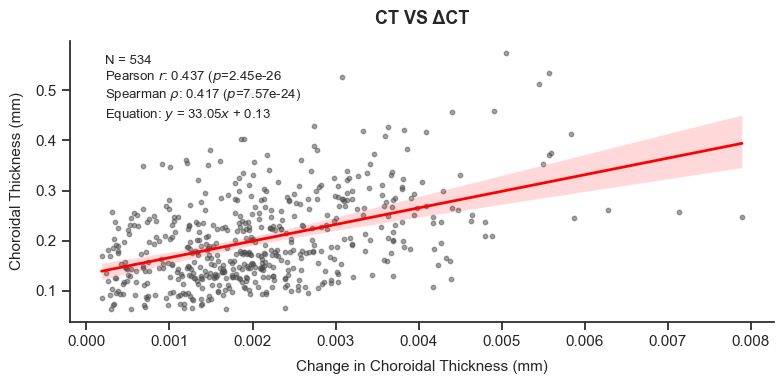

In [20]:
# | label: fig-ct-vs-delta-ct
with cm():
    fig, ax = plt.subplots(1, figsize=(8, 4), constrained_layout=True)
    regression_plot_with_stats(
        df=df,
        x="deltaCT",
        y="minCT",
        xlabel="Change in Choroidal Thickness (mm)",
        ylabel="Choroidal Thickness (mm)",
        title="CT VS ΔCT",
        ax=ax,
        equal_axis=False,
        print_stats=False,
    )
plt.show()


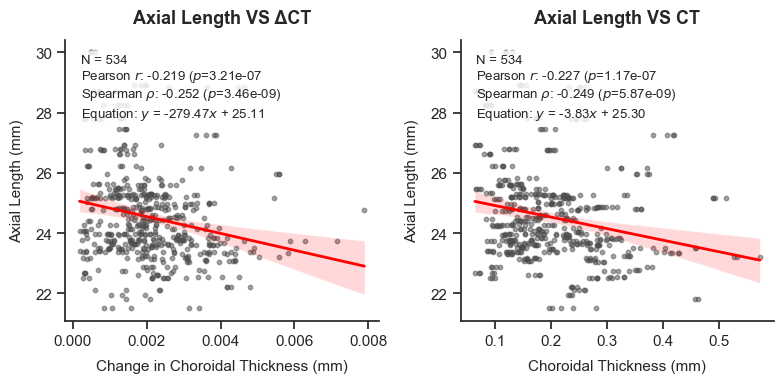

In [21]:
# | label: fig-axial-length-vs-delta-ct-and-ct
with cm():
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    regression_plot_with_stats(
        df=df,
        x="deltaCT",
        y="AxialLength",
        ylabel="Axial Length (mm)",
        xlabel="Change in Choroidal Thickness (mm)",
        title="Axial Length VS ΔCT",
        ax=axes[0],
        equal_axis=False,
        print_stats=False,
    )
    regression_plot_with_stats(
        df=df,
        x="minCT",
        y="AxialLength",
        ylabel="Axial Length (mm)",
        xlabel="Choroidal Thickness (mm)",
        title="Axial Length VS CT",
        ax=axes[1],
        equal_axis=False,
        print_stats=False,
    )
plt.show()

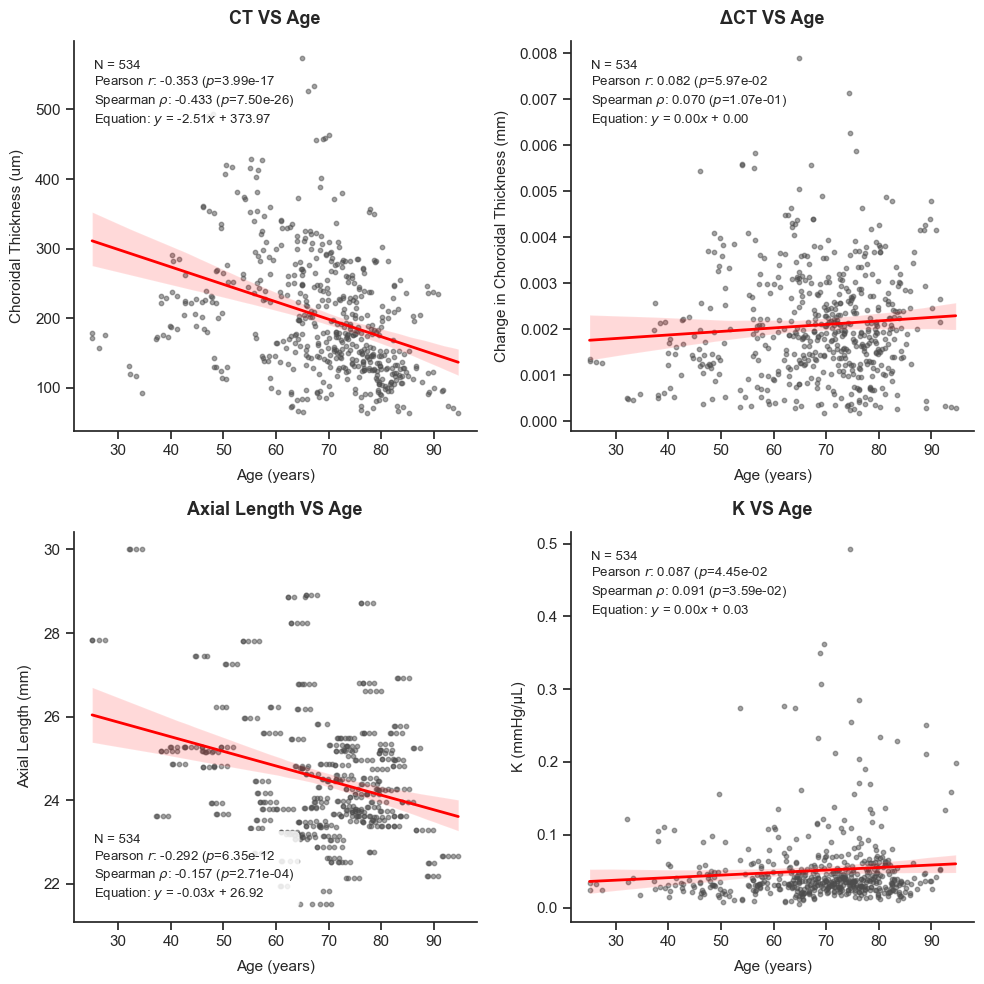

In [22]:
# | label: fig-K-deltaCT-deltaV-vs-age
with cm():
    fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
    df["minCT um"] = df["minCT"] * 1000
    regression_plot_with_stats(
        df=df,
        y="minCT um",
        x="Age",
        xlabel="Age (years)",
        ylabel="Choroidal Thickness (um)",
        title="CT VS Age",
        ax=axes[0, 0],
        equal_axis=False,
        print_stats=False,
    )
    regression_plot_with_stats(
        df=df,
        y="deltaCT",
        x="Age",
        xlabel="Age (years)",
        ylabel="Change in Choroidal Thickness (mm)",
        title="ΔCT VS Age",
        ax=axes[0, 1],
        equal_axis=False,
        print_stats=False,
    )
    regression_plot_with_stats(
        df=df,
        y="AxialLength",
        x="Age",
        xlabel="Age (years)",
        ylabel="Axial Length (mm)",
        title="Axial Length VS Age",
        ax=axes[1, 0],
        equal_axis=False,
        print_stats=False,
        legend_position="lower left",
    )
    regression_plot_with_stats(
        df=df,
        y="K",
        x="Age",
        xlabel="Age (years)",
        ylabel="K (mmHg/μL)",
        title="K VS Age",
        ax=axes[1, 1],
        equal_axis=False,
        print_stats=False,
    )

    plt.show()


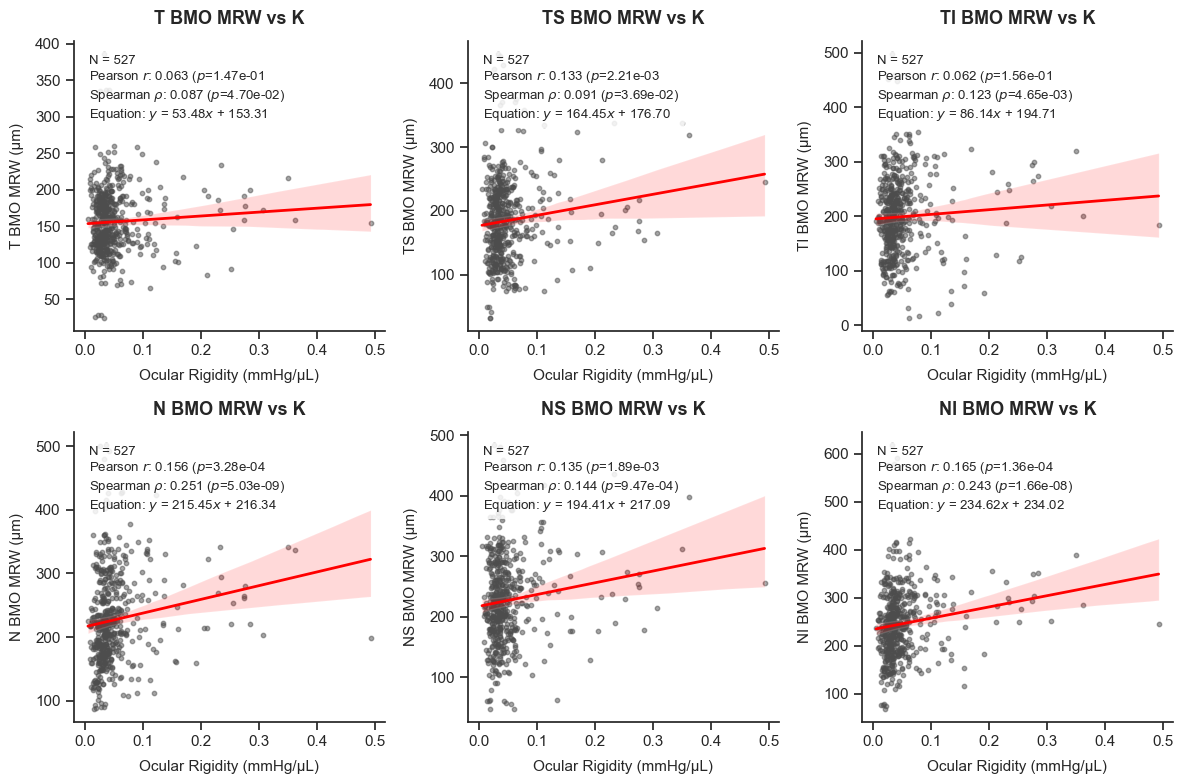

In [23]:
# | label: fig-K-vs-MRW
COLUMNS = [
    "T BMO MRW",
    "TS BMO MRW",
    "TI BMO MRW",
    "N BMO MRW",
    "NS BMO MRW",
    "NI BMO MRW",
]
with cm():
    fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
    for i, col in enumerate(COLUMNS):
        ax = axes[i // 3, i % 3]
        regression_plot_with_stats(
            df=df,
            x="K",
            y=col,
            xlabel="Ocular Rigidity (mmHg/μL)",
            ylabel=f"{col} (μm)",
            title=f"{col} vs K",
            ax=ax,
            equal_axis=False,
            print_stats=False,
        )
    plt.show()

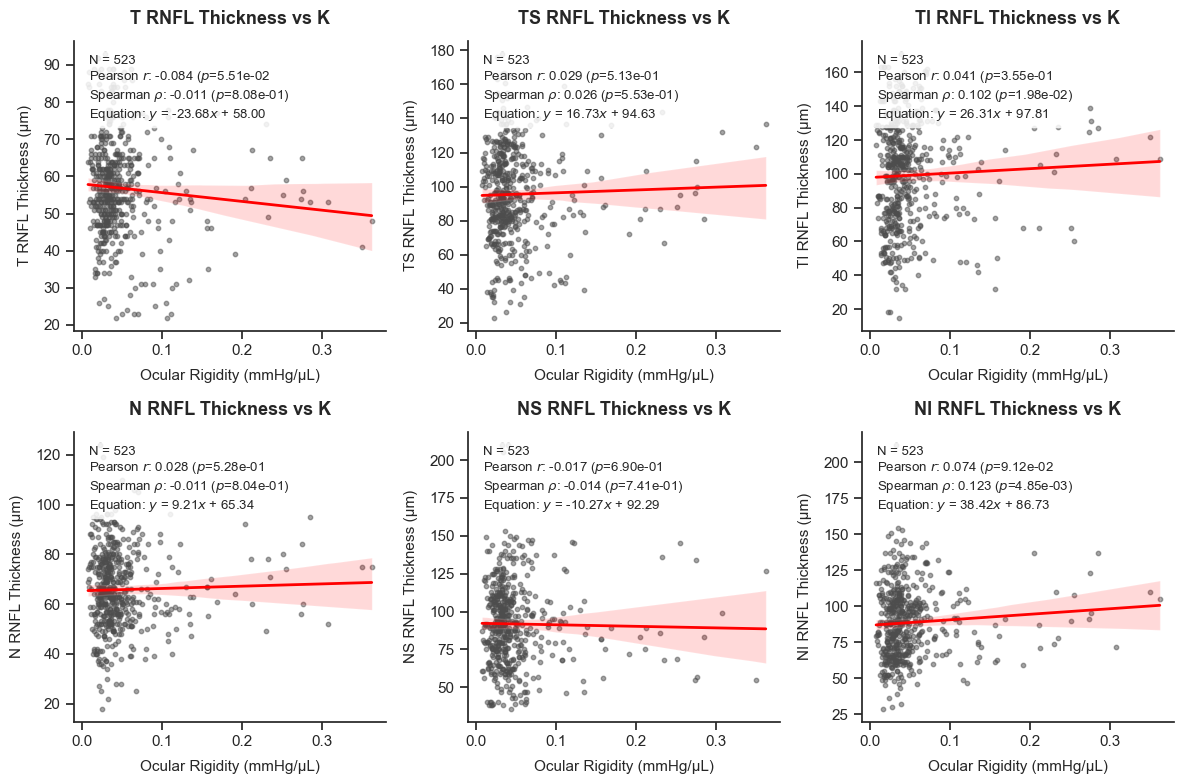

In [24]:
# | label: fig-K-vs-RNFL
COLUMNS = [
    "T RNFL Thickness",
    "TS RNFL Thickness",
    "TI RNFL Thickness",
    "N RNFL Thickness",
    "NS RNFL Thickness",
    "NI RNFL Thickness",
]
with cm():
    fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
    for i, col in enumerate(COLUMNS):
        ax = axes[i // 3, i % 3]
        regression_plot_with_stats(
            df=df,
            x="K",
            y=col,
            xlabel="Ocular Rigidity (mmHg/μL)",
            ylabel=f"{col} (μm)",
            title=f"{col} vs K",
            ax=ax,
            equal_axis=False,
            print_stats=False,
            drop_outlier_quantile=0.999,
        )
    plt.show()


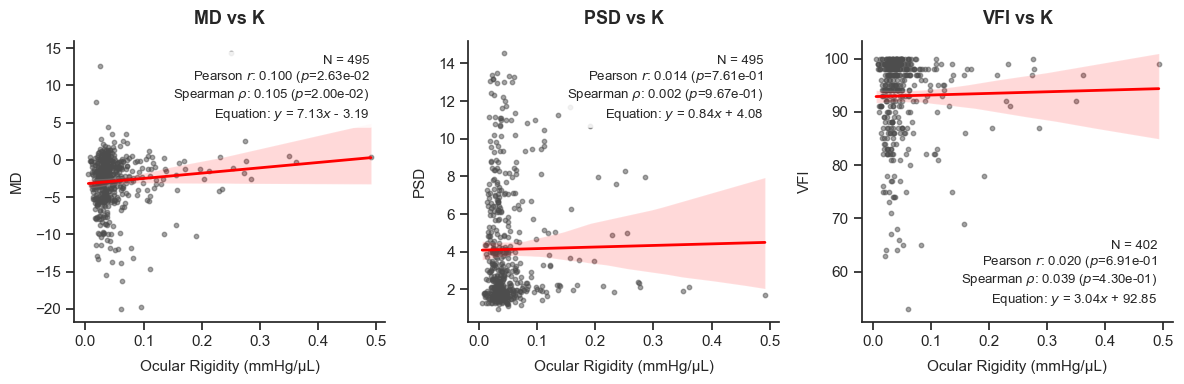

In [25]:
# | label: fig-K-vs-MD-PSD-VFI
COLUMNS = ["MD", "PSD", "VFI"]
with cm():
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    for i, col in enumerate(COLUMNS):
        ax = axes[i]
        regression_plot_with_stats(
            df=df,
            x="K",
            y=col,
            xlabel="Ocular Rigidity (mmHg/μL)",
            ylabel=f"{col}",
            title=f"{col} vs K",
            ax=ax,
            equal_axis=False,
            print_stats=False,
            legend_position="upper right" if i != 2 else "lower right",
        )
    plt.show()

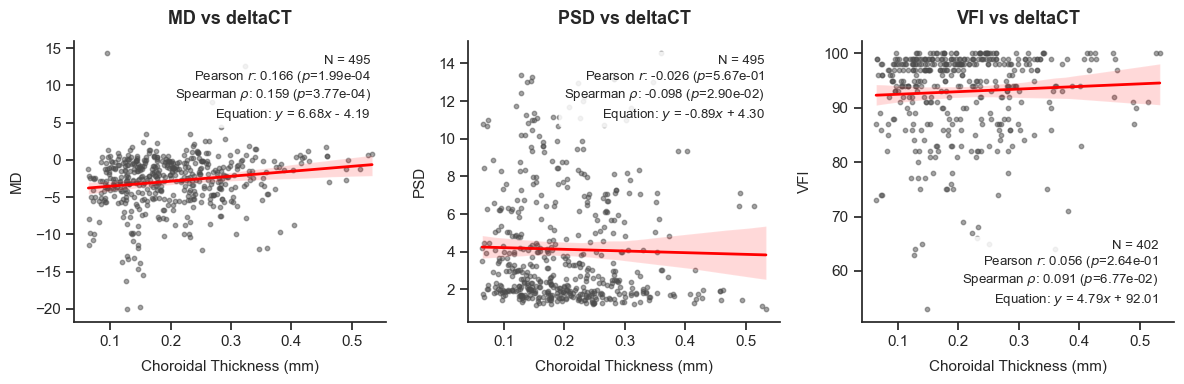

In [26]:
# | label: fig-CT-vs-MD-PSD-VFI
COLUMNS = ["MD", "PSD", "VFI"]
with cm():
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    for i, col in enumerate(COLUMNS):
        ax = axes[i]
        regression_plot_with_stats(
            df=df,
            x="minCT",
            y=col,
            xlabel="Choroidal Thickness (mm)",
            ylabel=f"{col}",
            title=f"{col} vs deltaCT",
            ax=ax,
            equal_axis=False,
            print_stats=False,
            legend_position="upper right" if i != 2 else "lower right",
        )
    plt.show()


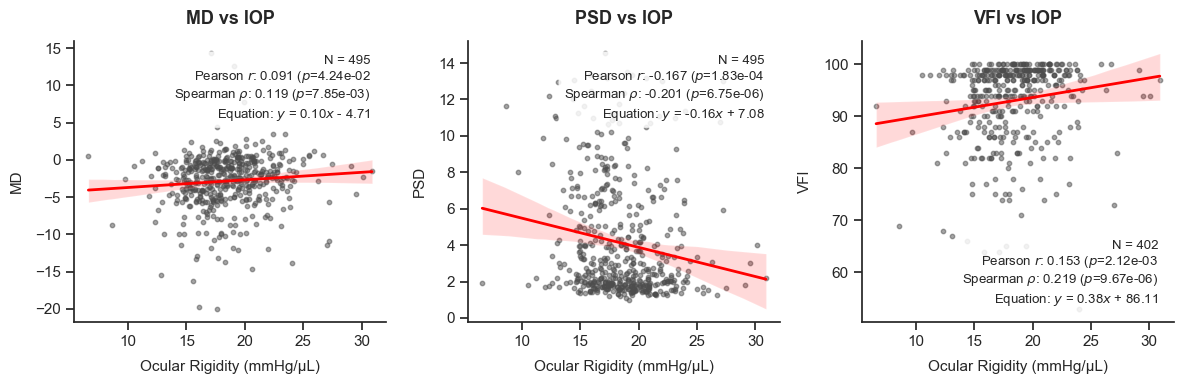

In [27]:
# | label: fig-IOP-vs-MD-PSD-VFI
COLUMNS = ["MD", "PSD", "VFI"]
with cm():
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    for i, col in enumerate(COLUMNS):
        ax = axes[i]
        regression_plot_with_stats(
            df=df,
            x="IOP",
            y=col,
            xlabel="Ocular Rigidity (mmHg/μL)",
            ylabel=f"{col}",
            title=f"{col} vs IOP",
            ax=ax,
            equal_axis=False,
            print_stats=False,
            legend_position="upper right" if i != 2 else "lower right",
        )
    plt.show()


Displaying plot: IOP vs OPA


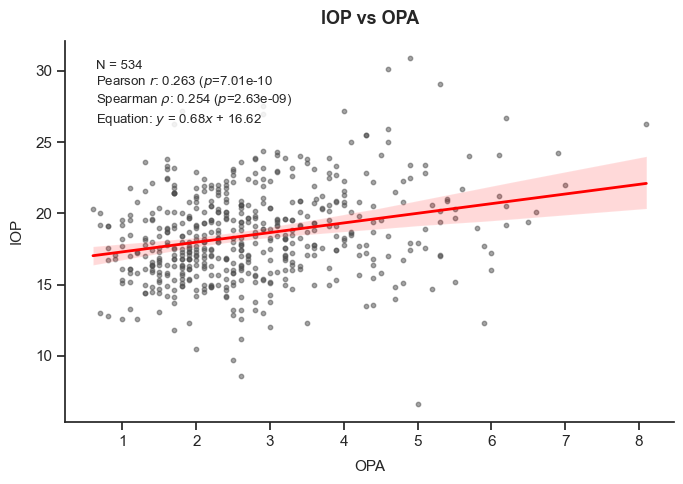

In [28]:
with cm():
    regression_plot_with_stats(
        df=df,
        x="OPA",
        y="IOP",
        xlabel="OPA",
        ylabel="IOP",
        title="IOP vs OPA",
        equal_axis=False,
        print_stats=False,
    )